### Practical Work

1. Train a RF on TF-8Bind data. 
2. Predict new sequences with SMW from seed sequence
3. Score unique unssen predicted sequences
4. best sequence == new seed
5. plot how good prediciton is against real world labels


In [1]:
# Imports
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# LSTM model^
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

SEED = 42

2026-01-13 10:51:05.855467: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Prepare Dataset: 
Der Trainingssatz, der den Offline-MBO-Algorithmen zur Verfügung gestellt wird, ist auf die unteren 50 % beschränkt, was zu einem sichtbaren Trainingssatz von 32898 Proben führt.

In [ ]:
# Load data and create train-test-split, one-hot encode sequences
df = pd.read_csv('tf_bind_8-SIX6_REF_R1/dataset.csv')

# sort dataframe by binding scores
df = df.sort_values(by='binding_scores').reset_index(drop=True)


# select 50% of data with lowest binding scores for training
train_size = int(0.5 * len(df))
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

# remix training data
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

x = train_df.iloc[:, :-2].values
y = train_df.iloc[:, -1].values
print(f'Training samples: {x.shape[0]}')

# Do the normalization on the training labels
mu = np.mean(y)
sigma = y.std()
if sigma != 0:
    y_train_norm = (y - mu) / sigma
else:
    y_train_norm = y - mu  # If std is 0, just center the data
print(f'Labels mean: {mu}, std: {sigma}')
print(f"Normalized y range: [{y_train_norm.min():.4f}, {y_train_norm.max():.4f}]")

# one hot encode sequences
x = tf.one_hot(x, depth=4)
x = x.numpy()  # Convert to numpy for train_test_split compatibility

x_train, x_test, y_train, y_test = train_test_split(x, y_train_norm, test_size=0.2, random_state=SEED)
print(f'One-hot encoded shape: {x_train.shape}')

   0  1  2  3  4  5  6  7  sequence  binding_scores
0  2  3  2  2  0  1  3  0  GTGGACTA        0.421721
1  2  0  0  3  2  0  0  1  GAATGAAC        0.365408
2  0  2  0  2  2  0  1  2  AGAGGACG        0.396745
3  1  2  1  0  2  0  3  2  CGCAGATG        0.357533
4  2  2  0  0  2  1  2  0  GGAAGCGA        0.395106
Training samples: 32896
Labels mean: 0.32612651033351164, std: 0.07644532823068272
Normalized y range: [-4.2661, 1.4804]
One-hot encoded shape: (26316, 8, 4)


Next cell creates a dataframe with binding scores and one hot encoded sequences for the lookup task. 

In [42]:
# create dataframe for lookup task
df_oracle = test_df[['0', '1', '2', '3', '4', '5', '6', '7', 'binding_scores']] # try oracle with all sequences df instead of only train_df
x_oracle = df_oracle.iloc[:, :-1].values
df_oracle['one_hot_seq'] = [tf.one_hot(seq, depth=4).numpy().flatten() for seq in x_oracle]
df_oracle.drop(columns=df_oracle.columns[:-2], inplace=True)

# print highest value and lowest value in oracle
print(f'Oracle binding score range: {df_oracle["binding_scores"].min()} - {df_oracle["binding_scores"].max()}')

Oracle binding score range: 0.43929616 - 1.0


In [43]:
def oracle_lookup(one_hot_sequence):
    """Looks up the real binding score for a given one-hot encoded sequence."""
    flattened_seq = one_hot_sequence.flatten()
    match = df_oracle[df_oracle['one_hot_seq'].apply(lambda x: np.array_equal(x, flattened_seq))]
    if not match.empty:
        return match['binding_scores'].values[0]
    else:
        return 0.0  # no score if not found

In [46]:
rf = RandomForestRegressor(n_estimators=50, max_depth=20, min_samples_leaf=5, random_state=SEED)

# flatten training data
flat_shape = x_train.shape[1] * x_train.shape[2]
x_reshaped = x_train.reshape(x_train.shape[0], flat_shape)

rf.fit(x_reshaped, y_train)

# Evaluation just on a few samples from test set
x_test = x_test.reshape(x_test.shape[0], flat_shape)

y_prediction = rf.predict(x_test)
r2 = r2_score(y_test, y_prediction)
mse = mean_squared_error(y_test, y_prediction)

r2_train = r2_score(y_train, rf.predict(x_reshaped))
print(f'R2 Score on train set: {r2_train}')
print(f'R2 Score: {r2}; MSE: {mse}')

R2 Score on train set: 0.4401714549893532
R2 Score: 0.14470469841400568; MSE: 0.849551262001837


In [44]:
import numpy as np
import tensorflow as tf

class SMW:

    def __init__(self, nucleotides):
        self.nucleotides = nucleotides
        self.n = len(nucleotides)

    def one_hot_encode(self, sequence):
        sequence_tensor = tf.one_hot(
            sequence, depth=4
        )
        sequence_numpy = sequence_tensor.numpy() 
        shape = sequence_numpy.shape[0] * sequence_numpy.shape[1]
        sequence_n_flat = sequence_numpy.reshape(1, shape)
        return sequence_n_flat

    def mutate_sequence(self, sequence, pos):
        sequence = list(sequence)
        if pos is None:
            pos = np.random.randint(0, len(sequence))
        # Get current nucleotide and possible mutations, make sure that nuc is different
        current_nucleotide = sequence[pos]
        possible_mutations = [nuc for nuc in self.nucleotides if nuc !=
                                current_nucleotide]
        # Replace nucleotide at position 
        new_nucleotide = np.random.choice(possible_mutations)
        sequence[pos] = new_nucleotide
        return sequence
        
    def walk(self, start_sequence, n_steps):
        current_seq = start_sequence
        history = []
        for step in range(n_steps):
            mutant = self.mutate_sequence(current_seq, None)
            mutant_one_hot = self.one_hot_encode(mutant)
            #mutant_fitness = fitness_function(mutant_one_hot)

            # Check if mutant is better than current
            # Yes: move to mutant
            #if mutant_fitness > current_fitness:
            current_seq = mutant
            #    current_fitness = mutant_fitness

            history.append(mutant_one_hot)
        return history


#### LSTM Model 

In [109]:
#Lstm model for sequence generation
model = Sequential()
model.add(LSTM(100, input_shape = (x.shape[1:])))
model.add(Dense(4, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.load_weights('lstm_sequence_model.h5')

model.summary()

def generate_sequence(seed_sequence, next_chars, max_sequence_len):
    for _ in range(next_chars):
        token_list = tf.one_hot(seed_sequence, depth=4)
        token_list = tf.reshape(token_list, (1, token_list.shape[0], token_list.shape[1]))
        predicted = model.predict(token_list, verbose=0)
        predicted_char = tf.argmax(predicted, axis=1).numpy()[0]
        seed_sequence.append(predicted_char)
        if len(seed_sequence) > max_sequence_len:
            seed_sequence = seed_sequence[1:]
    return seed_sequence

def generate_mutations(seed_sequence, n_mutations):
    mutations = []
    seed_sequence = seed_sequence[-1]
    for _ in range(n_mutations):
        mutated_sequence = generate_sequence(seed_sequence.copy(), next_chars=1, max_sequence_len=len(seed_sequence))
        mutations.append(mutated_sequence)
        seed_sequence = mutated_sequence[-1] # update seed to last generated character
    return mutations


/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 100)            │        42,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,404 (165.64 KB)

 Trainable params: 42,404 (165.64 KB)

 Non-trainable params: 0 (0.00 B)

#### Main Loop

In [16]:
## Main Loop
n_steps = 100
mutation_steps = 1
use_SMW = True

seed_sequence = tf.argmax(x_train[1300], axis=1).numpy().tolist()
if use_SMW: 
    # Start from a seed sequence in the training data (convert one-hot to integer indices)
    smw = SMW(nucleotides=[0, 1, 2, 3])


# Flatten x_train for comparison
x_train_flat = x_train.reshape(x_train.shape[0], flat_shape)

df_all_values = pd.DataFrame({'mutation': [], 'predicted_score': [], 'real_score': [], 'error': []})

def calculate_error(predicted_scores, real_scores):
    errors = []
    for pred, real in zip(predicted_scores, real_scores):
        error = abs(pred - real)
        errors.append(error)
    return errors

score_prev = -1
seen_sequences = x_train_flat

for i in range(n_steps):
    values = {'mutation': [], 'predicted_score': []}
    if not use_SMW:
        mutations = generate_mutations(seed_sequence, mutation_steps)
        # one-hot encode mutations
        mutations = [tf.one_hot(mut, depth=4).numpy().reshape(1, flat_shape) for mut in mutations]
    else: 
        mutations = smw.walk(seed_sequence, mutation_steps)

    # check if mutations are in train data
    for idx, mut in enumerate(mutations):
        # Check if mutation is NOT in training data (try with complete dataset)
        already_seen = np.any(np.all(seen_sequences == mut, axis=1))
        if not already_seen:
            # If not in training data, add to list
            mutations_score = rf.predict(mut)
            values['mutation'].append(mut)
            values['predicted_score'].append(mutations_score[0])
        
    
    # Select best mutation -> highest value
    # sort values by predicted score -> highest score first
    values_df = pd.DataFrame(values)
    values_df_sorted = values_df.sort_values(by='predicted_score', ascending=False)
    # keep only top 1
    values_df_sorted = values_df_sorted.head(1)
    # append to all values dataframe for later analysis
    df_all_values = pd.concat([df_all_values, values_df_sorted], ignore_index=True)

    # update seed sequence to best mutation -> highes predicted score
    if len(values_df_sorted) == 0:
        print(f'Step {i+1}/{n_steps}, No new mutations found.')
        continue

    # update seed sequence only if score is higher than previous best
    value_new =values_df_sorted.iloc[0]["predicted_score"]
    if value_new > score_prev:
        score_prev = value_new
        seed_sequence_one_hot = values_df_sorted.iloc[0]['mutation']
        seed_sequence = tf.argmax(tf.reshape(seed_sequence_one_hot, (seed_sequence_one_hot.shape[1]//4, 4)), axis=1).numpy().tolist()
        print(f'Step {i+1}/{n_steps}, Best predicted score: {values_df_sorted.iloc[0]["predicted_score"]}')
    else:
        print(f'Step {i+1}/{n_steps}, No better mutation found. Keeping previous seed sequence.')    
    
    # make shure not to check seen sequences again
    if len(values['mutation']) > 0:
        new_mutations = np.vstack(values['mutation'])
        seen_sequences = np.vstack([seen_sequences, new_mutations])
    print(f'New seed sequence: {seed_sequence}')


Step 1/100, Best predicted score: 0.31103947703114854
New seed sequence: [2, 1, 0, 2, 1, 0, 3, 1]
Step 2/100, No new mutations found.
Step 3/100, No new mutations found.
Step 4/100, No new mutations found.
Step 5/100, Best predicted score: 0.3495075629043081
New seed sequence: [2, 1, 0, 2, 0, 0, 3, 1]
Step 6/100, No new mutations found.
Step 7/100, Best predicted score: 0.35243496077308706
New seed sequence: [2, 0, 0, 2, 0, 0, 3, 1]
Step 8/100, No new mutations found.
Step 9/100, Best predicted score: 0.3668750974124414
New seed sequence: [2, 0, 0, 2, 0, 0, 3, 0]
Step 10/100, No better mutation found. Keeping previous seed sequence.
New seed sequence: [2, 0, 0, 2, 0, 0, 3, 0]
Step 11/100, No new mutations found.
Step 12/100, Best predicted score: 0.3735530323720976
New seed sequence: [2, 0, 0, 2, 3, 0, 3, 0]
Step 13/100, Best predicted score: 0.3778451882084978
New seed sequence: [1, 0, 0, 2, 3, 0, 3, 0]
Step 14/100, No better mutation found. Keeping previous seed sequence.
New seed se

In [ ]:
#lookup real scores and calculate error
for index, row in df_all_values.iterrows():
    real_score = oracle_lookup(row['mutation'])
    df_all_values.at[index, 'real_score'] = real_score
    error = abs(row['predicted_score'] - real_score)
    df_all_values.at[index, 'error'] = error

print(df_all_values.head(10))

                                            mutation  predicted_score  \
0  [[0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0,...         0.311039   
1  [[0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0,...         0.349508   
2  [[0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0,...         0.352435   
3  [[0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0,...         0.366875   
4  [[0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0,...         0.335968   
5  [[0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0,...         0.373553   
6  [[0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0,...         0.377845   
7  [[0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0,...         0.354068   
8  [[0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0,...         0.374625   
9  [[0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0,...         0.371116   

   real_score     error  
0    1.484310  1.173271  
1    1.851079  1.501572  
2    2.355521  2.003086  
3    3.121287  2.754412  
4    3.252892  2.916924  
5    6.042223  5.668670  
6    5.503666 

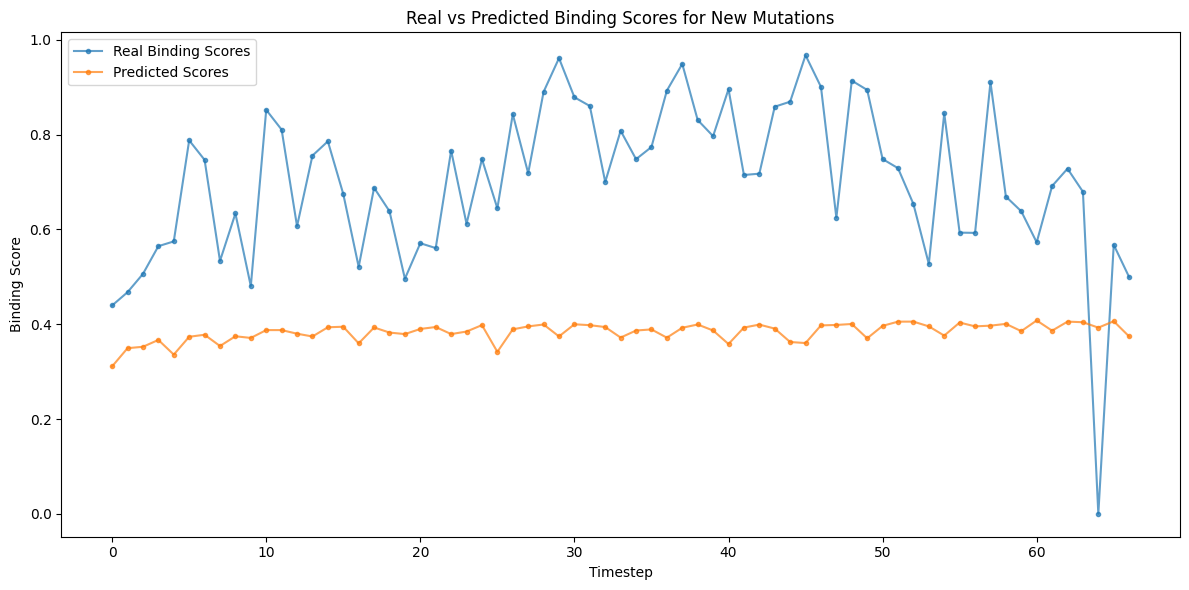

In [18]:
import matplotlib.pyplot as plt


real_scores = df_all_values['real_score']
predicted_scores = df_all_values['predicted_score']
# Plot real vs predicted scores
plt.figure(figsize=(12, 6))
# Downsample to every 10th point for better visibility
step = 1
indices = range(0, len(real_scores), step)
real_scores_sampled = real_scores.iloc[::step]
predicted_scores_sampled = predicted_scores.iloc[::step]
plt.plot(range(len(real_scores_sampled)), real_scores_sampled, label='Real Binding Scores', alpha=0.7, marker='o', markersize=3)
plt.plot(range(len(predicted_scores_sampled)), predicted_scores_sampled, label='Predicted Scores', alpha=0.7, marker='o', markersize=3)
plt.xlabel('Timestep')
plt.ylabel('Binding Score')
plt.title('Real vs Predicted Binding Scores for New Mutations')
plt.legend()
plt.tight_layout()
plt.show()

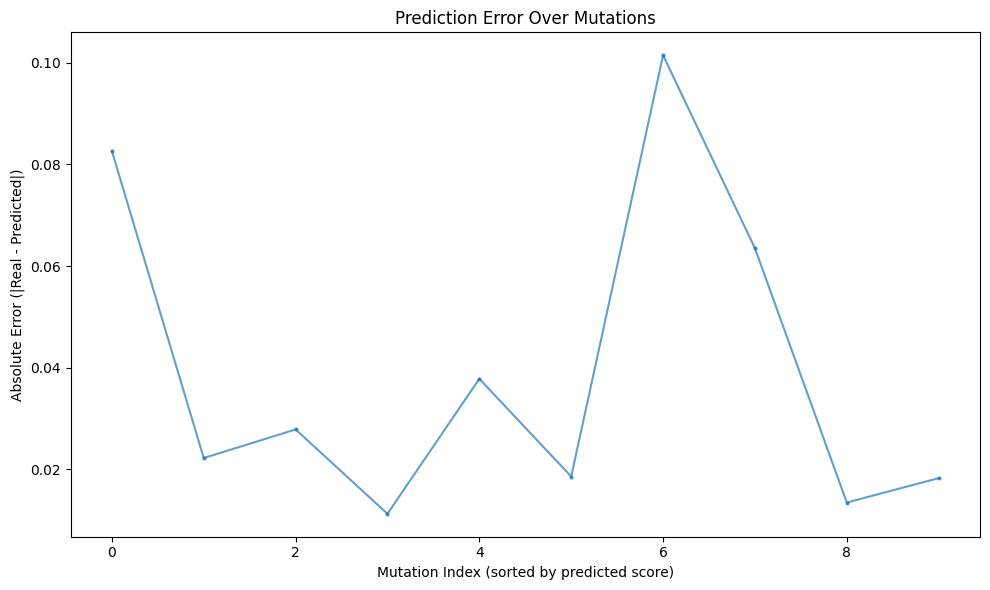

In [10]:
# Calculate absolute error for each mutation
errors = [abs(real - pred) for real, pred in zip(real_scores, predicted_scores)]

# Plot error over mutation index
plt.figure(figsize=(10, 6))
plt.plot(range(len(errors)), errors, marker='o', markersize=2, alpha=0.7)
plt.xlabel('Mutation Index (sorted by predicted score)')
plt.ylabel('Absolute Error (|Real - Predicted|)')
plt.title('Prediction Error Over Mutations')
plt.tight_layout()
plt.show()

# Also plot a rolling average to see the trend more clearly
window_size = 20
if len(errors) >= window_size:
    rolling_errors = pd.Series(errors).rolling(window=window_size).mean()
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(errors)), errors, alpha=0.3, label='Individual Errors')
    plt.plot(range(len(rolling_errors)), rolling_errors, color='red', linewidth=2, label=f'Rolling Average (window={window_size})')
    plt.xlabel('Mutation Index (sorted by predicted score)')
    plt.ylabel('Absolute Error')
    plt.title('Prediction Error with Rolling Average')
    plt.legend()
    plt.tight_layout()
    plt.show()

### Another Approach
1. One Mutation from Single Mutant Walker
2. Predict with RF
3. Normalize Predicted score to range 0-1
4. If score is higher -> save sequence else continue with old seed
5. Lookup real scores and plot trajectories

Step 1/100, New best mutation with predicted score: 0.40419457831590155
Step 1/100, New best mutation with predicted score: 0.7209573469345765
Step 4/100, New best mutation with predicted score: 0.8697571732174596
Step 4/100, New best mutation with predicted score: 0.9172300124260014
Step 18/100, New best mutation with predicted score: 0.977481197715376
Step 22/100, New best mutation with predicted score: 0.9862692464918031
Step 29/100, New best mutation with predicted score: 1.0167209105247847
Step 50/100, New best mutation with predicted score: 1.030816254462085
Step 85/100, New best mutation with predicted score: 1.0456280832096354
Step 87/100, New best mutation with predicted score: 1.0626041261335089
Step 88/100, New best mutation with predicted score: 1.0854444826342702


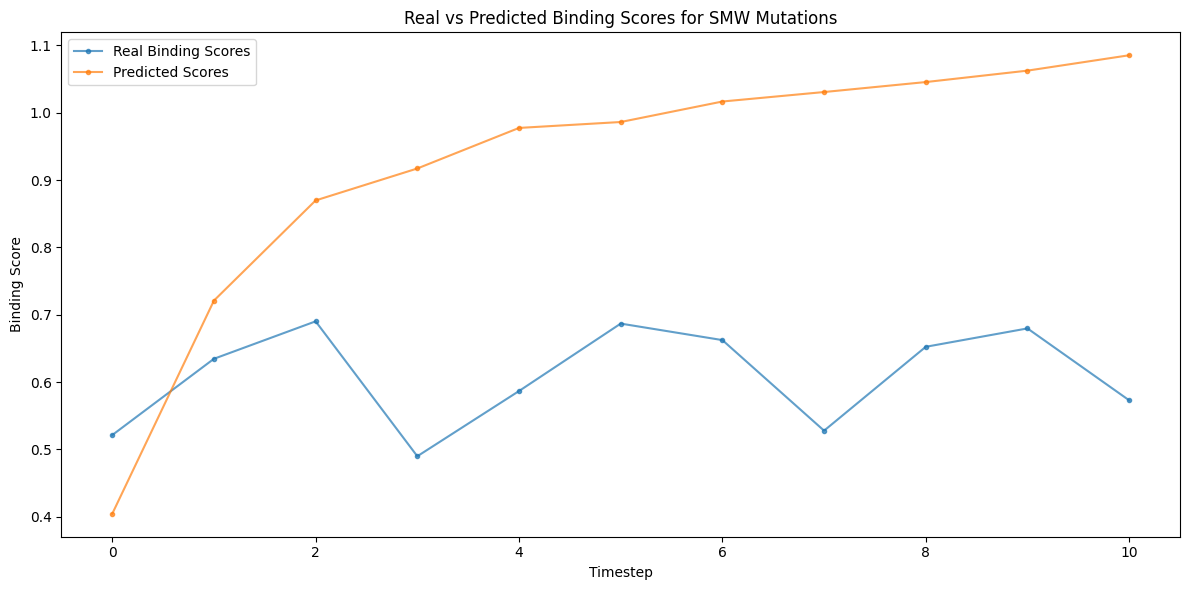

In [51]:
# Initialize SMW 
smw = SMW(nucleotides=[0, 1, 2, 3])
n_steps = 100
mutation_steps = 10

seen_sequences = x_train_flat

seed_sequence = tf.argmax(x_train[1300], axis=1).numpy().tolist()
old_binding_score = y_train[1300]

values = {'mutation': [], 'predicted_score': []}

min_score = df_oracle['binding_scores'].min()
max_score = df_oracle['binding_scores'].max()

for i in range(n_steps):
    # Generate one mutation using SMW
    mutations = smw.walk(seed_sequence, mutation_steps)  # Get the first mutation
    # Check if mutation is new
    for idx, mutation in enumerate(mutations):
        already_seen = np.any(np.all(seen_sequences == mutation, axis=1))
        if not already_seen:
            binding_score = rf.predict(mutation)
            if binding_score[0] > old_binding_score:
                # Update seed sequence
                seed_sequence = tf.argmax(tf.reshape(mutation, (mutation.shape[1]//4, 4)), axis=1).numpy().tolist()
                old_binding_score = binding_score[0]
                values['mutation'].append(mutation)
                # normalize binding score to 0-1 range based on oracle min/max
                #normalized_score = -(binding_score[0] - min_score) / (max_score - min_score)
                values['predicted_score'].append(binding_score[0])
                print(f'Step {i+1}/{n_steps}, New best mutation with predicted score: {binding_score[0]}')
            else:
                continue

# Lookup real binding score
df_values = pd.DataFrame(values)
df_values['real_score'] = df_values['mutation'].apply(oracle_lookup)
df_values['error'] = abs(df_values['predicted_score'] - df_values['real_score'])

# Plot results 
plt.figure(figsize=(12, 6))
plt.plot(df_values['real_score'], label='Real Binding Scores', alpha=0.7, marker='o', markersize=3)
plt.plot(df_values['predicted_score'], label='Predicted Scores', alpha=0.7, marker='o', markersize=3)
plt.xlabel('Timestep')
plt.ylabel('Binding Score')
plt.title('Real vs Predicted Binding Scores for SMW Mutations')
plt.legend()
plt.tight_layout()
plt.show()